In [ ]:
#### ChatGPT was used to help write this code

In [1]:
# imports
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
import warnings

In [2]:
# load data
df_att_all = pd.read_csv('attendance data with features.csv')

# remove unnecessary features
# duplicates, linearly dependent variables, etc.

remove = ['H', 'V',
          'HGP', 'VGP',
          'HPTS', 'VPTS',
          'HGF', 'VGF',
          'HGA', 'VGA',
          'HPP%', 'VPP%', 
          'HPK%', 'HPK%',
          'HS', 'VS', 
          'HSA', 'VSA']

df_att = df_att_all.drop(columns = remove)

# Set random seed
rand_seed = 34

In [3]:
# Define models
models = {
    "OLS": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

# regularization parameters
# optimal values for l1_alpha found in Data Feature Selection
lasso_A = 3.59
lasso_LA = 0.000129
lasso_PA = 0.000279

ridge_A = 0.5
ridge_LA = 0.1
ridge_PA = 0.1

# Define model parameters for each dependent variable type
model_params = {
    "A": {
        "OLS": {},
        "Lasso": {'alpha': lasso_A},
        "Ridge": {'alpha': ridge_A},
        "ElasticNet": {
            'alpha': (lasso_A + ridge_A) * 0.25,  # Sum of Lasso and Ridge alphas, multiplied by 0.25 to avoid over-regularization
            'l1_ratio': lasso_A / (lasso_A + ridge_A)  # Ratio based on Lasso strength
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 100, 'learning_rate': 0.1, 'random_state': rand_seed}
    },
    "LA": {
        "OLS": {},
        "Lasso": {'alpha': lasso_LA},
        "Ridge": {'alpha': ridge_LA},
        "ElasticNet": {
            'alpha': (lasso_LA + ridge_LA) * 0.25,
            'l1_ratio': lasso_LA / (lasso_LA + ridge_LA)
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 200, 'learning_rate': 0.1, 'random_state': rand_seed}
    },
    "PA": {
        "OLS": {},
        "Lasso": {'alpha': lasso_PA},
        "Ridge": {'alpha': ridge_PA},
        "ElasticNet": {
            'alpha': (lasso_PA + ridge_PA) * 0.25,
            'l1_ratio': lasso_PA / (lasso_PA + ridge_PA)
        },
        "Decision Tree": {'max_depth': 15, 'random_state': rand_seed},
        "Random Forest": {'n_estimators': 100, 'random_state': rand_seed},
        "Gradient Boosting": {'n_estimators': 100, 'learning_rate': 0.1, 'random_state': rand_seed}
    }
}

In [4]:
# Function to compute evaluation metrics with dependent variable transformation
def compute_stats(dep, X_train, X_test, y_train, y_train_pred, y_test, y_test_pred):
    if dep == 'A':
        y_train_true, y_train_pred = y_train, y_train_pred
        y_test_true, y_test_pred = y_test, y_test_pred

    elif dep == 'LA':
        y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
        y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)

    elif dep == 'PA':
        y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
        y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']

    return {
        "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
        "R² Train": r2_score(y_train_true, y_train_pred),
        "RMSE Test": sqrt(mean_squared_error(y_test_true, y_test_pred)),
        "MAE Test": mean_absolute_error(y_test_true, y_test_pred),
        "R² Test": r2_score(y_test_true, y_test_pred)
    }

In [5]:
def run_model(model, model_name, X_train, X_test, y_train, y_test, dep, model_params):
    # Select the correct parameters for the given dep
    params = model_params[dep].get(model_name)

    # If the model is 'Lasso', 'ElasticNet', or 'Ridge', scale the features
    if model_name in ["Lasso", "ElasticNet"]:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.set_params(**params)  # Set the parameters for the model
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.set_params(**params)  # Set the parameters for the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
    
    return {"Model": model_name, **compute_stats(dep, X_train, X_test, y_train, y_train_pred, y_test, y_test_pred)}

In [6]:
def plot_predict(models, X_train, X_test, y_train, y_test, dep, model_params):    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Plot actual vs. predicted for each model
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, (name, model) in enumerate(models.items()):
        # Select the correct parameters for the given dep
        params = model_params[dep].get(name)
        
        # Fit and predict for the model
        if name in ["Lasso", "ElasticNet"]:
            # Scale features for Lasso and ElasticNet
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            model.set_params(**params)  # Set the parameters
            model.fit(X_train_scaled, y_train)
            y_train_pred = model.predict(X_train_scaled)
            y_test_pred = model.predict(X_test_scaled)
        else:
            model.set_params(**params)  # Set the parameters
            model.fit(X_train, y_train)
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

        # Apply dependent variable transformations and plot accordingly
        if dep == 'LA':
            y_test_la = np.exp(y_test)
            y_test_pred_la = np.exp(y_test_pred)

            ax = axes[i]
            ax.scatter(y_test_la, y_test_pred_la, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test_la), max(y_test_la)], [min(y_test_la), max(y_test_la)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Log-Transformed)")
            ax.set_xlabel("Actual Attendance (Log)")
            ax.set_ylabel("Predicted Attendance (Log)")

        elif dep == 'PA':
            y_test_pa = y_test * X_test['CAP']
            y_test_pred_pa = y_test_pred * X_test['CAP']

            ax = axes[i]
            ax.scatter(y_test_pa, y_test_pred_pa, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test_pa), max(y_test_pa)], [min(y_test_pa), max(y_test_pa)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Capacity Adjusted)")
            ax.set_xlabel("Actual Attendance (Capacity Adjusted)")
            ax.set_ylabel("Predicted Attendance (Capacity Adjusted)")

        else:
            ax = axes[i]
            ax.scatter(y_test, y_test_pred, alpha=0.5, color='red', marker='.')
            ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--')
            ax.set_title(f"{name}: Actual vs. Predicted (Original)")
            ax.set_xlabel("Actual Attendance")
            ax.set_ylabel("Predicted Attendance")

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

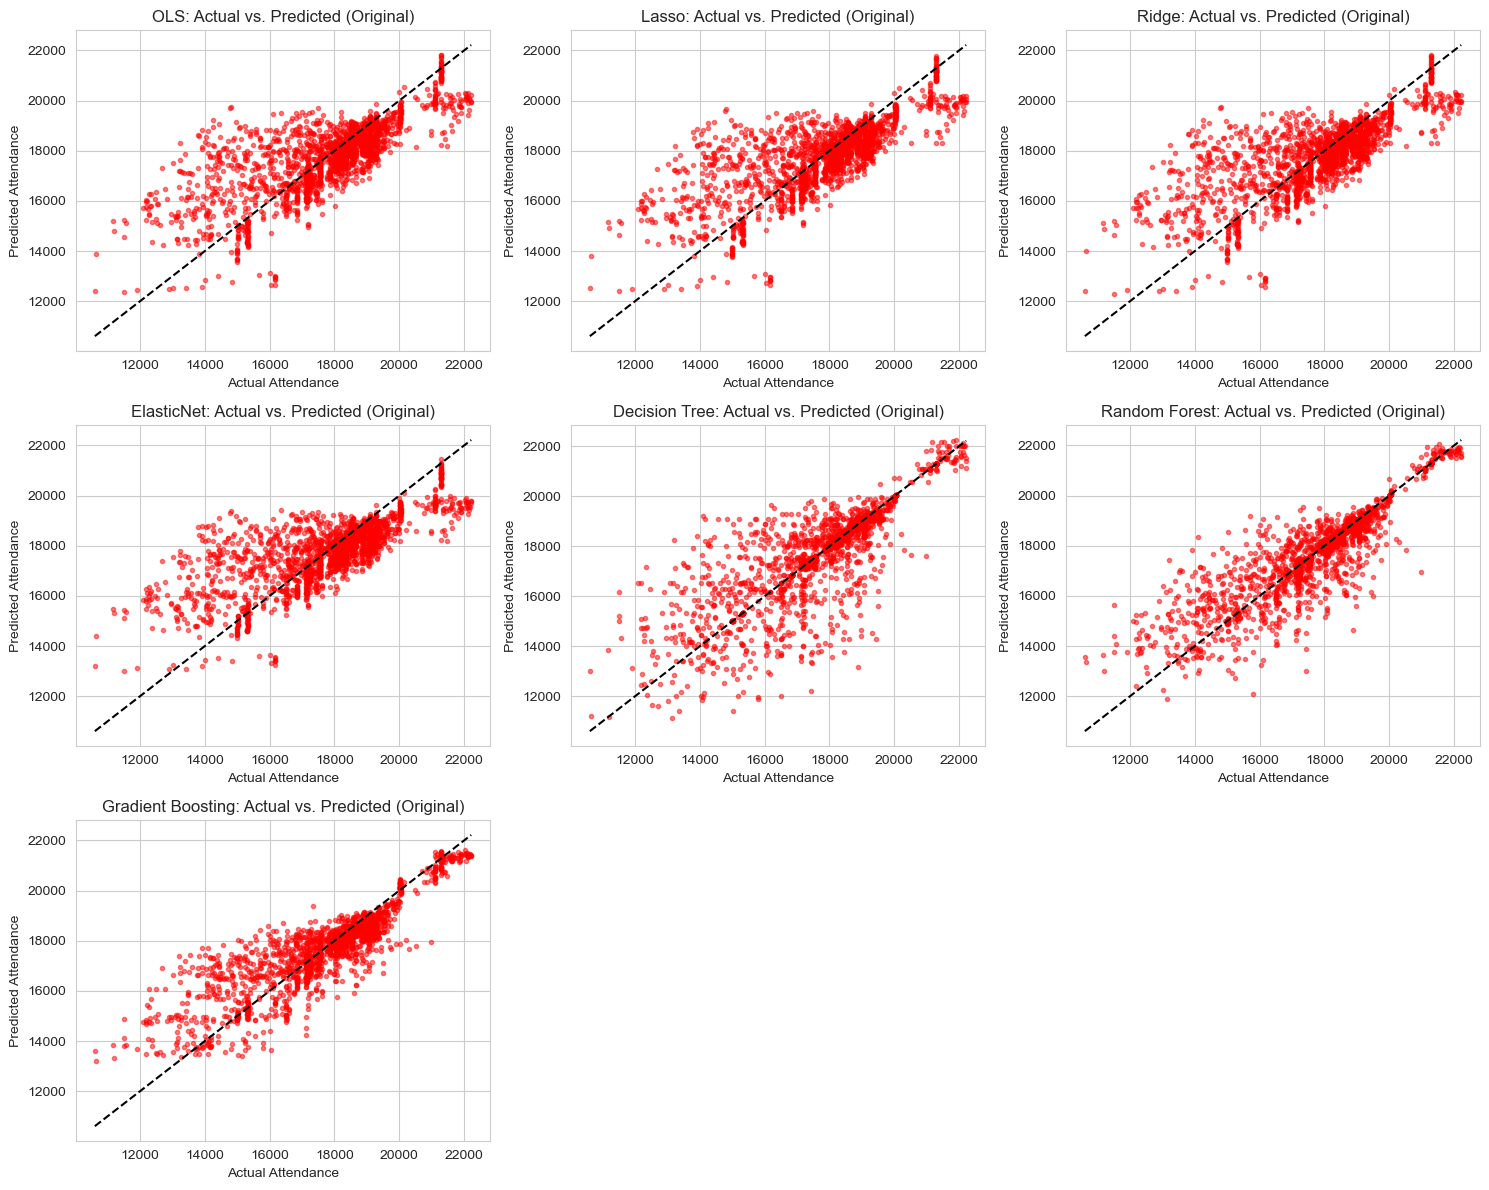

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1284.010158,905.416822,0.544490,1294.041254,914.090346,0.559761
1,Lasso,1286.382485,906.668584,0.542805,1297.210188,917.678082,0.557603
2,Ridge,1285.953857,907.855970,0.543110,1295.963021,916.984046,0.558453
3,ElasticNet,1306.442272,922.242855,0.528435,1317.566356,937.863353,0.543609
4,Decision Tree,296.712356,122.589100,0.975676,1183.062890,667.263601,0.632034
5,Random Forest,343.770864,199.633650,0.967349,909.920252,536.280449,0.782330
6,Gradient Boosting,893.764085,611.623696,0.779298,955.594767,652.365195,0.759929


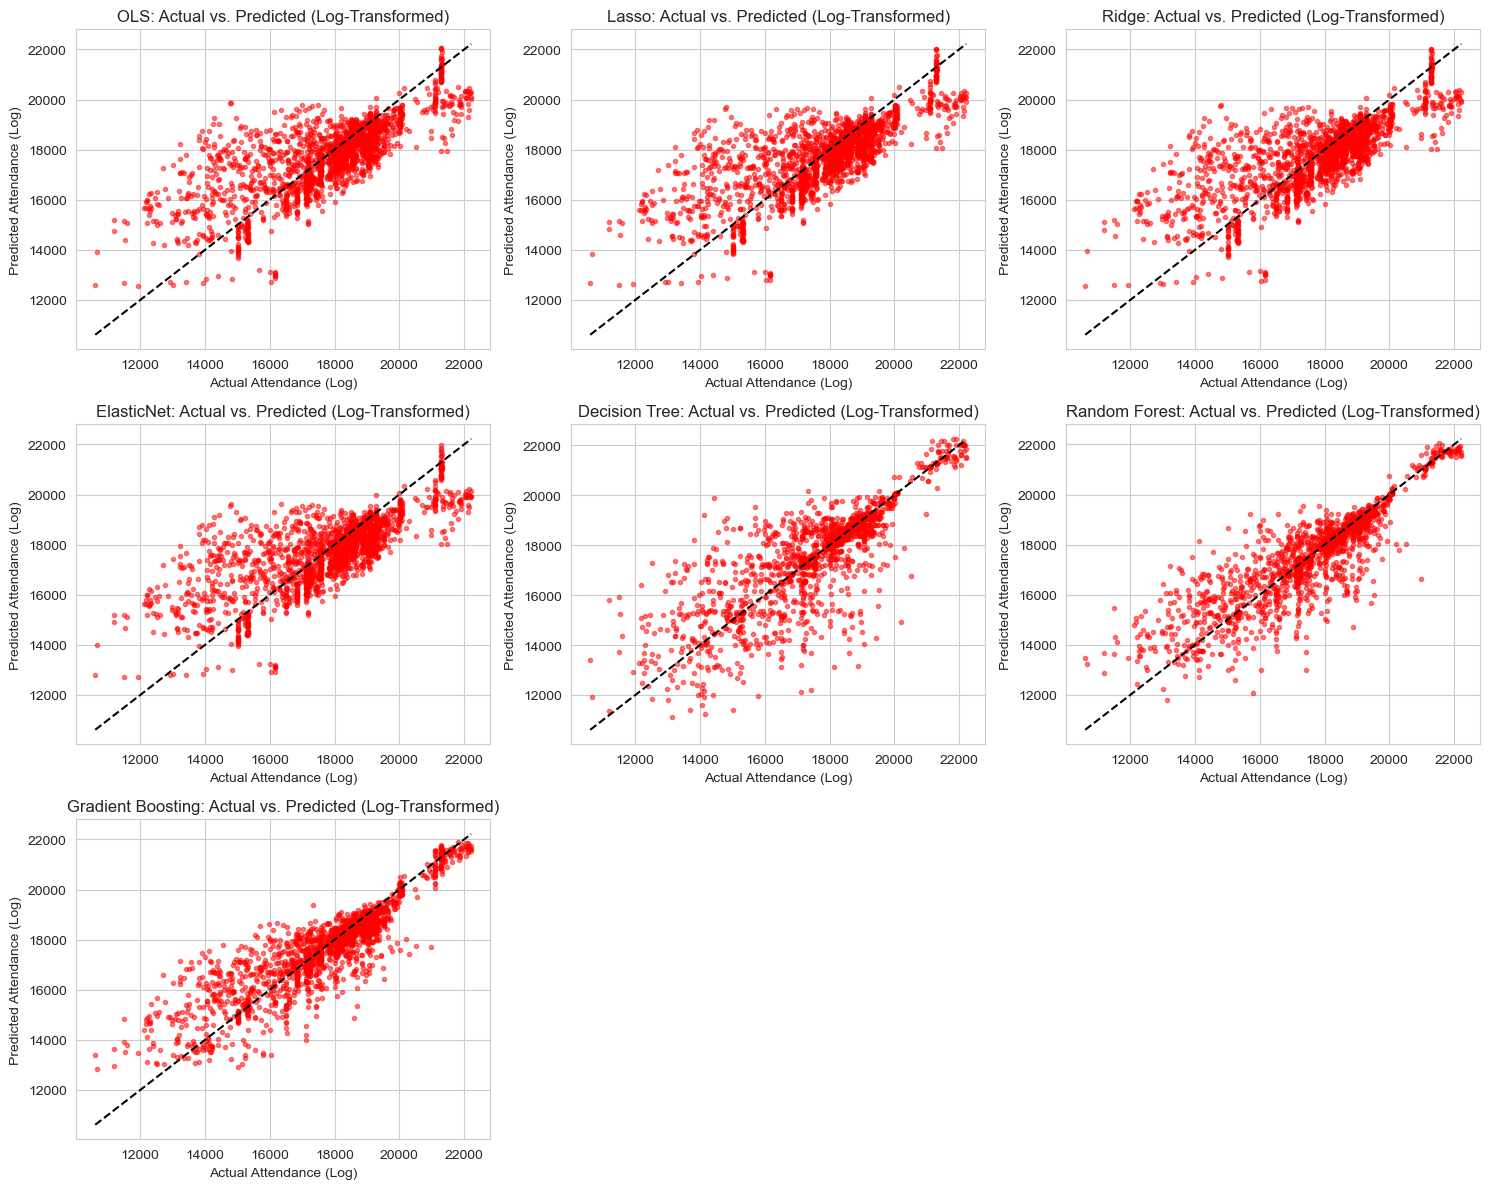

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1289.775030,930.389078,0.540391,1298.111218,937.695516,0.556988
1,Lasso,1288.636025,928.754539,0.541202,1296.293942,936.388930,0.558227
2,Ridge,1287.912937,928.013405,0.541717,1294.890211,934.600392,0.559184
3,ElasticNet,1292.052893,931.142512,0.538766,1299.992506,939.987124,0.555703
4,Decision Tree,387.229281,171.534857,0.958572,1121.082791,633.921847,0.669579
5,Random Forest,343.474816,200.019864,0.967405,902.388713,533.746963,0.785918
6,Gradient Boosting,796.351071,542.829994,0.824786,901.410879,602.777018,0.786382


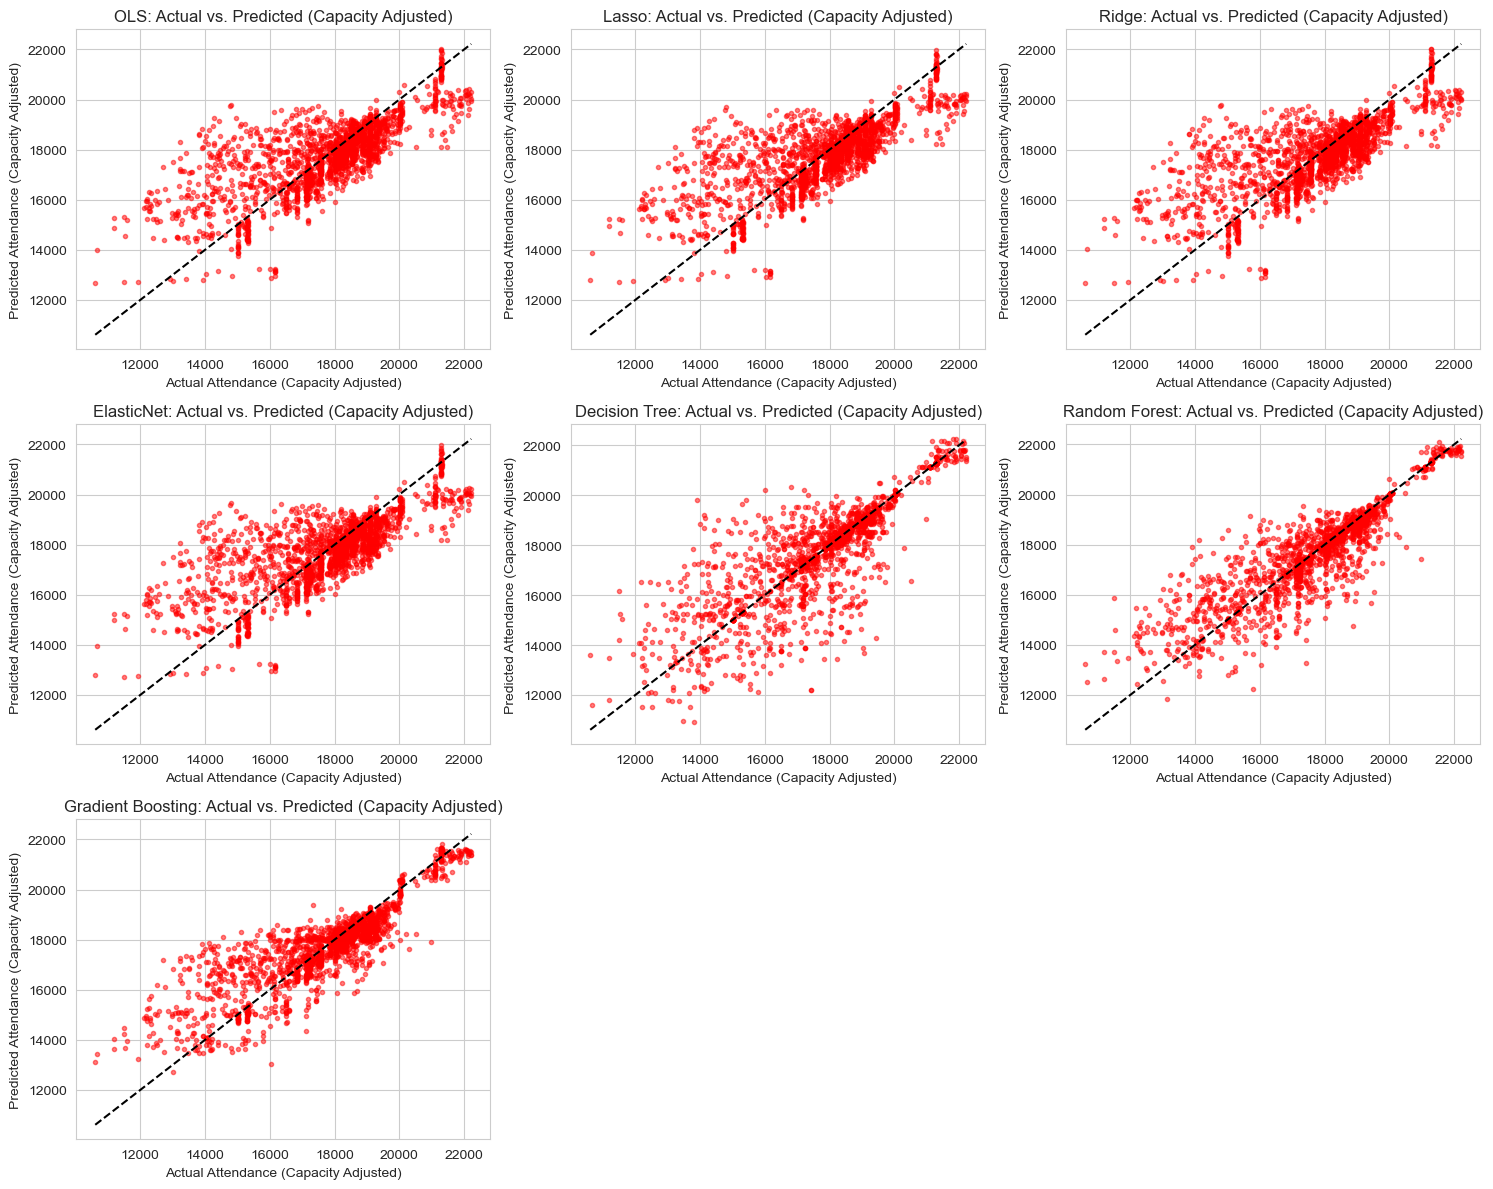

,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,OLS,1284.686129,907.506380,0.544010,1294.055809,915.433846,0.559751
1,Lasso,1288.544017,909.572260,0.541268,1299.514260,921.191901,0.556030
2,Ridge,1284.720265,907.682660,0.543986,1294.225422,916.185040,0.559636
3,ElasticNet,1289.366870,910.366197,0.540682,1300.221566,921.860478,0.555546
4,Decision Tree,343.045611,140.195913,0.967486,1156.265444,651.015553,0.648515
5,Random Forest,344.344787,200.291474,0.967240,895.617110,532.158929,0.789119
6,Gradient Boosting,917.879964,625.265901,0.767227,978.606408,664.681558,0.748228


In [7]:
# Dependent variable
deps = ['A', 'LA', 'PA']

for dep in deps:
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])

    y = df_att[dep]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_seed)

    results = [run_model(model, name, X_train, X_test, y_train, y_test, dep, model_params) for name, model in models.items()]
    df_results = pd.DataFrame(results)

    plot_predict(models, X_train, X_test, y_train, y_test, dep, model_params)

    display(df_results)

In [8]:
def kfold_cv(model, model_name, X, y, dep, model_params, n_splits=5):
    kf = KFold(n_splits=n_splits)#, shuffle=True, random_state=rand_seed)
    results = []

    # Set model parameters if available
    params = model_params.get(dep, {}).get(model_name, {})
    
    for train_index, val_index in kf.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Extract the 'CAP' column before scaling if it's present
        cap_train = X_train['CAP'] if 'CAP' in X_train.columns else None
        cap_val = X_val['CAP'] if 'CAP' in X_val.columns else None

        # Scaling for Lasso and ElasticNet
        if model_name in ["Lasso", "ElasticNet"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

        # Initialize model with the parameters from model_params (if any)
        if params:
            model.set_params(**params)

        # Fit the model
        # model.fit(X_train, y_train)

        # Fit the model with warning capture
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_train, y_train)
            
            # Print convergence warnings with context
            for warning in w:
                if issubclass(warning.category, ConvergenceWarning):
                    print(f"⚠️ Convergence warning during {model_name} on {dep}: {warning.message}")
        
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Apply dependent variable transformation based on `dep`
        if dep == 'A':
            y_train_true, y_train_pred = y_train, y_train_pred
            y_val_true, y_val_pred = y_val, y_val_pred
        elif dep == 'LA':
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_val_true, y_val_pred = np.exp(y_val), np.exp(y_val_pred)
        elif dep == 'PA':
            if cap_train is not None:
                y_train_true, y_train_pred = y_train * cap_train, y_train_pred * cap_train
                y_val_true, y_val_pred = y_val * cap_val, y_val_pred * cap_val
            else:
                raise ValueError("CAP column is missing in the dataset.")

        # Compute evaluation metrics
        metrics = {
            "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
            "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
            "R² Train": r2_score(y_train_true, y_train_pred),
            "RMSE Test": sqrt(mean_squared_error(y_val_true, y_val_pred)),
            "MAE Test": mean_absolute_error(y_val_true, y_val_pred),
            "R² Test": r2_score(y_val_true, y_val_pred)
        }

        results.append(metrics)

    # Convert results to DataFrame and compute average scores
    results_df = pd.DataFrame(results)
    avg_scores = results_df.mean().to_dict()
    avg_scores["Model"] = model_name  # Add model name for reference

    return avg_scores

In [9]:
# Dependent variable
deps = ['A', 'LA', 'PA']

for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1272.767222,903.476648,0.556237,1439.855042,1054.710742,0.416418,OLS
1,1275.708872,905.362895,0.554182,1425.629122,1046.528569,0.427692,Lasso
2,1275.261708,905.845436,0.554521,1431.181347,1049.738936,0.424121,Ridge
3,1297.204502,921.480014,0.539033,1421.534883,1048.380128,0.431403,ElasticNet
4,341.835165,145.618272,0.967755,1565.334031,973.198857,0.280184,Decision Tree
5,351.155089,201.192483,0.966184,1160.771136,775.296223,0.608450,Random Forest
6,889.574798,604.081106,0.782966,1195.019769,862.501565,0.590508,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1277.345045,925.853310,0.553027,1450.311107,1080.454975,0.406972,OLS
1,1278.270512,927.104827,0.552375,1435.536565,1071.518107,0.418822,Lasso
2,1277.210405,925.712480,0.553120,1442.766732,1074.783612,0.413487,Ridge
3,1282.057990,929.794188,0.549716,1433.808923,1073.389086,0.420681,ElasticNet
4,372.309060,167.514422,0.962045,1508.022154,962.281700,0.326764,Decision Tree
5,350.272538,201.099467,0.966356,1211.388986,802.219009,0.567909,Random Forest
6,795.383740,539.885041,0.826494,1236.731280,897.298766,0.558978,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1273.678204,905.622035,0.555584,1435.458775,1051.892152,0.419635,OLS
1,1278.156302,908.414814,0.552452,1418.540232,1042.396860,0.432933,Lasso
2,1273.830744,905.690931,0.555480,1429.799130,1048.270813,0.424552,Ridge
3,1279.199720,909.293316,0.551717,1419.804086,1045.882392,0.432253,ElasticNet
4,407.475342,179.937635,0.953627,1691.824058,1074.469361,0.161053,Decision Tree
5,350.496357,200.858955,0.966322,1240.084950,848.021899,0.554005,Random Forest
6,906.526486,613.332650,0.774628,1212.825215,874.844822,0.579804,Gradient Boosting


In [10]:
# Define Random Forest hyperparameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200, 500, 750],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': ['sqrt', 'log2', None]
}

# Define Gradient Boosting hyperparameter grid
gb_param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# Initialize models
rf = RandomForestRegressor(random_state=rand_seed)
gb = GradientBoostingRegressor(random_state=rand_seed)

# Initialize RandomizedSearchCV with TimeSeriesSplit
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,  # Number of different combinations to try
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

gb_random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

In [11]:
# Initialize an empty dictionary to store the best parameters
best_params = {}

for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Fit Random Forest model
    rf_random_search.fit(X, y)
    best_params[f"RandomForest_{dep}"] = rf_random_search.best_params_

    print(f'done RF for {dep}')
    
    # Fit Gradient Boosting model
    gb_random_search.fit(X, y)
    best_params[f"GradientBoosting_{dep}"] = gb_random_search.best_params_

    print(f'done XGBoost for {dep}')

# Create a DataFrame from the best_params dictionary
best_params_df = pd.DataFrame.from_dict(best_params, orient='index')

# Replace NaN values with '-' for better readability
best_params_df = best_params_df.fillna('-')

# Display the DataFrame
print("\nBest Parameters DataFrame:")
display(best_params_df)

done RF for A
done XGBoost for A
done RF for LA
done XGBoost for LA
done RF for PA
done XGBoost for PA

Best Parameters DataFrame:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,learning_rate
RandomForest_A,200,20,5,-,-,-
GradientBoosting_A,200,5,10,-,5.0,0.05
RandomForest_LA,200,20,5,-,-,-
GradientBoosting_LA,100,2,1,-,5.0,0.1
RandomForest_PA,50,10,5,sqrt,30.0,-
GradientBoosting_PA,100,5,5,-,5.0,0.1


In [12]:
# column names
columns = ["Dep", "Model", "RMSE Train", "MAE Train", "R² Train", "RMSE Test", "MAE Test", "R² Test"]

# initialize results list
results_list = []

# Loop through dependent variables and apply the best model for each
for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:  # For 'LA'
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Select model type based on dependent variable
    rf_params = best_params[f"RandomForest_{dep}"]
    gb_params = best_params[f"GradientBoosting_{dep}"]

    # Train and evaluate both models
    for model_name, model_params, model_class in [
        ("Random Forest", rf_params, RandomForestRegressor),
        ("Gradient Boosting", gb_params, GradientBoostingRegressor)
    ]:
        # Instantiate the model with optimized hyperparameters
        model = model_class(random_state=rand_seed, **model_params)

        # Fit the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # **Adjust predictions based on dependent variable transformation**
        if dep == 'LA':  # Log Attendance was used → Apply exp()
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)
        elif dep == 'PA':  # Percentage Attendance → Multiply by CAP
            y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
            y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']
        else:  # 'A' (Raw Attendance) → No adjustment needed
            y_train_true, y_train_pred = y_train, y_train_pred
            y_test_true, y_test_pred = y_test, y_test_pred

        # Compute evaluation metrics
        rmse_train = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
        mae_train = mean_absolute_error(y_train_true, y_train_pred)
        r2_train = r2_score(y_train_true, y_train_pred)

        rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
        mae_test = mean_absolute_error(y_test_true, y_test_pred)
        r2_test = r2_score(y_test_true, y_test_pred)

        # Store results in a list
        results_list.append({
            "Dep": dep,
            "Model": model_name,
            "RMSE Train": rmse_train,
            "MAE Train": mae_train,
            "R² Train": r2_train,
            "RMSE Test": rmse_test,
            "MAE Test": mae_test,
            "R² Test": r2_test
        })

        # Scatter plot for actual vs predicted values
        fig, ax = plt.subplots(figsize=(6, 6))  # Define figure size
        ax.scatter(y_test_true, y_test_pred, alpha=0.5, color='red', marker='.', s=10)
        ax.plot([min(y_test_true), max(y_test_true)], [min(y_test_true), max(y_test_true)], 
                color='black', linestyle='--', label="Ideal Fit")  # Ideal fit line
        ax.set_title(f"{model_name} Optimized: Actual vs. Predicted ({dep})")
        ax.set_xlabel("Actual Attendance")
        ax.set_ylabel("Predicted Attendance")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
        plt.savefig(f"kfold_{model_name}_{dep}_actual_vs_predicted_all_feat.png", dpi=300, bbox_inches='tight')
        plt.close()

# Convert list to DataFrame
df_results = pd.DataFrame(results_list)[columns]

# Display results table
df_results

,Dep,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,A,Random Forest,651.314409,388.657178,0.884264,869.252527,513.364616,0.791276
1,A,Gradient Boosting,713.811917,467.241069,0.860987,867.272942,552.602039,0.792226
2,LA,Random Forest,656.888749,392.466020,0.882274,873.597378,516.175146,0.789184
3,LA,Gradient Boosting,682.354277,461.193189,0.872970,866.625672,562.242831,0.792536
4,PA,Random Forest,676.631212,406.380344,0.875091,889.124001,526.059547,0.781624
5,PA,Gradient Boosting,703.587820,461.870674,0.864941,873.620974,554.710241,0.789173


In [13]:
### TIME SERIES CROSS VALIDATION

def time_series_cv(model, model_name, X, y, dep, model_params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []

    # Set model parameters if available
    params = model_params.get(dep, {}).get(model_name, {})
    
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Extract the 'CAP' column before scaling if it's present
        cap_train = X_train['CAP'] if 'CAP' in X_train.columns else None
        cap_val = X_val['CAP'] if 'CAP' in X_val.columns else None

        # Scaling for Lasso and ElasticNet
        if model_name in ["Lasso", "ElasticNet"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)

        # Initialize model with the parameters from model_params (if any)
        if params:
            model.set_params(**params)

        # Fit the model
        #model.fit(X_train, y_train)

        # Fit the model with warning capture
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_train, y_train)
            
            # Print convergence warnings with context
            for warning in w:
                if issubclass(warning.category, ConvergenceWarning):
                    print(f"⚠️ Convergence warning during {model_name} on {dep}: {warning.message}")
        
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Apply dependent variable transformation based on `dep`
        if dep == 'A':
            y_train_true, y_train_pred = y_train, y_train_pred
            y_val_true, y_val_pred = y_val, y_val_pred
        elif dep == 'LA':
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_val_true, y_val_pred = np.exp(y_val), np.exp(y_val_pred)
        elif dep == 'PA':
            if cap_train is not None:
                y_train_true, y_train_pred = y_train * cap_train, y_train_pred * cap_train
                y_val_true, y_val_pred = y_val * cap_val, y_val_pred * cap_val
            else:
                raise ValueError("CAP column is missing in the dataset.")

        # Compute evaluation metrics
        metrics = {
            "RMSE Train": sqrt(mean_squared_error(y_train_true, y_train_pred)),
            "MAE Train": mean_absolute_error(y_train_true, y_train_pred),
            "R² Train": r2_score(y_train_true, y_train_pred),
            "RMSE Test": sqrt(mean_squared_error(y_val_true, y_val_pred)),
            "MAE Test": mean_absolute_error(y_val_true, y_val_pred),
            "R² Test": r2_score(y_val_true, y_val_pred)
        }

        results.append(metrics)

    # Convert results to DataFrame and compute average scores
    results_df = pd.DataFrame(results)
    avg_scores = results_df.mean().to_dict()
    avg_scores["Model"] = model_name  # Add model name for reference

    return avg_scores

In [14]:
# Dependent variable
deps = ['A', 'LA', 'PA']  # Change to 'LA' or 'PA' if needed

for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Run all models with TimeSeriesSplit CV
    cv_results = [time_series_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.069e+09, tolerance: 7.354e+05
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.436e+09, tolerance: 1.434e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.019e+09, tolerance: 2.157e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.527e+09, tolerance: 2.752e+06
⚠️ Convergence warning during Lasso on A: Ob

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1225.885407,875.190519,0.630712,1422.135572,1036.409894,0.403486,OLS
1,1226.928554,875.860183,0.630099,1418.192554,1035.407157,0.407256,Lasso
2,1232.155719,874.409711,0.627179,1413.511121,1027.482275,0.412525,Ridge
3,1234.006687,875.163393,0.625922,1391.138482,1011.703022,0.430067,ElasticNet
4,320.212796,123.002852,0.973126,1698.375671,1118.158514,0.157381,Decision Tree
5,357.193704,199.457714,0.968863,1220.293618,860.856922,0.562598,Random Forest
6,818.011082,538.305918,0.835255,1213.159649,887.202907,0.561941,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1232.390750,899.780609,0.626893,1446.201693,1072.163643,0.384215,OLS
1,1236.236449,896.562950,0.624577,1414.806866,1044.703012,0.411757,Lasso
2,1237.521644,899.935162,0.624053,1433.395582,1060.852545,0.396791,Ridge
3,1239.909448,899.334215,0.622389,1405.473592,1040.428613,0.419177,ElasticNet
4,309.908736,117.905702,0.975496,1748.889482,1181.727612,0.103970,Decision Tree
5,356.511772,199.608117,0.968977,1249.669708,897.273195,0.538073,Random Forest
6,816.704104,546.995708,0.835769,1233.152895,910.852723,0.548273,Gradient Boosting


⚠️ Convergence warning during Lasso on PA: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.069e-03, tolerance: 2.106e-03


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1225.983967,878.172081,0.630656,1430.020509,1043.379755,0.397685,OLS
1,1232.316460,875.828684,0.626874,1401.228589,1017.831969,0.422705,Lasso
2,1231.400768,877.066694,0.627637,1418.917715,1032.481468,0.408599,Ridge
3,1234.496976,876.191261,0.625593,1394.164116,1014.404474,0.428056,ElasticNet
4,302.651841,114.897504,0.975639,1870.521395,1229.905750,-0.033914,Decision Tree
5,357.967262,199.228499,0.968728,1297.822643,922.470183,0.502613,Random Forest
6,823.461388,542.492934,0.832519,1285.560898,945.080592,0.517829,Gradient Boosting


In [15]:
# Define TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Define Random Forest hyperparameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200, 500, 750],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': ['sqrt', 'log2', None]
}

# Define Gradient Boosting hyperparameter grid
gb_param_grid = {
    'n_estimators': [50, 100, 200, 500, 750],
    'learning_rate': [0.001, 0.005, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [1, 2, 3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# Initialize models
rf = RandomForestRegressor(random_state=rand_seed)
gb = GradientBoostingRegressor(random_state=rand_seed)

# Initialize RandomizedSearchCV with TimeSeriesSplit
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,  # Number of different combinations to try
    cv=tscv,  # Use TimeSeriesSplit
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

gb_random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=rand_seed,
    n_jobs=-1
)

In [16]:
# Initialize an empty dictionary to store the best parameters
best_params = {}

for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Fit Random Forest model
    rf_random_search.fit(X, y)
    best_params[f"RandomForest_{dep}"] = rf_random_search.best_params_

    print(f'done RF for {dep}')
    
    # Fit Gradient Boosting model
    gb_random_search.fit(X, y)
    best_params[f"GradientBoosting_{dep}"] = gb_random_search.best_params_

    print(f'done XGBoost for {dep}')

# Create a DataFrame from the best_params dictionary
best_params_df = pd.DataFrame.from_dict(best_params, orient='index')

# Replace NaN values with '-' for better readability
best_params_df = best_params_df.fillna('-')

# Display the DataFrame
print("\nBest Parameters DataFrame:")
display(best_params_df)

done RF for A
done XGBoost for A
done RF for LA
done XGBoost for LA
done RF for PA
done XGBoost for PA

Best Parameters DataFrame:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,learning_rate
RandomForest_A,200,20,5,-,-,-
GradientBoosting_A,500,5,1,-,3.0,0.01
RandomForest_LA,500,20,5,-,10.0,-
GradientBoosting_LA,500,10,10,-,3.0,0.01
RandomForest_PA,50,10,5,sqrt,30.0,-
GradientBoosting_PA,200,5,10,-,5.0,0.05


In [17]:
# column names
columns = ["Dep", "Model", "RMSE Train", "MAE Train", "R² Train", "RMSE Test", "MAE Test", "R² Test"]

# initialize results list
results_list = []

# Loop through dependent variables and apply the best model for each
for dep in ['A', 'LA', 'PA']:
    # Prepare features and target variable
    if dep in ['A', 'PA']:
        X = df_att.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:  # For 'LA'
        X = df_att.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att[dep]
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Select model type based on dependent variable
    rf_params = best_params[f"RandomForest_{dep}"]
    gb_params = best_params[f"GradientBoosting_{dep}"]

    # Train and evaluate both models
    for model_name, model_params, model_class in [
        ("Random Forest", rf_params, RandomForestRegressor),
        ("Gradient Boosting", gb_params, GradientBoostingRegressor)
    ]:
        # Instantiate the model with optimized hyperparameters
        model = model_class(random_state=rand_seed, **model_params)

        # Fit the model
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # **Adjust predictions based on dependent variable transformation**
        if dep == 'LA':  # Log Attendance was used → Apply exp()
            y_train_true, y_train_pred = np.exp(y_train), np.exp(y_train_pred)
            y_test_true, y_test_pred = np.exp(y_test), np.exp(y_test_pred)
        elif dep == 'PA':  # Percentage Attendance → Multiply by CAP
            y_train_true, y_train_pred = y_train * X_train['CAP'], y_train_pred * X_train['CAP']
            y_test_true, y_test_pred = y_test * X_test['CAP'], y_test_pred * X_test['CAP']
        else:  # 'A' (Raw Attendance) → No adjustment needed
            y_train_true, y_train_pred = y_train, y_train_pred
            y_test_true, y_test_pred = y_test, y_test_pred

        # Compute evaluation metrics
        rmse_train = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
        mae_train = mean_absolute_error(y_train_true, y_train_pred)
        r2_train = r2_score(y_train_true, y_train_pred)

        rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
        mae_test = mean_absolute_error(y_test_true, y_test_pred)
        r2_test = r2_score(y_test_true, y_test_pred)

        # Store results in a list
        results_list.append({
            "Dep": dep,
            "Model": model_name,
            "RMSE Train": rmse_train,
            "MAE Train": mae_train,
            "R² Train": r2_train,
            "RMSE Test": rmse_test,
            "MAE Test": mae_test,
            "R² Test": r2_test
        })

        # Scatter plot for actual vs predicted values
        fig, ax = plt.subplots(figsize=(6, 6))  # Define figure size
        ax.scatter(y_test_true, y_test_pred, alpha=0.5, color='red', marker='.', s=10)
        ax.plot([min(y_test_true), max(y_test_true)], [min(y_test_true), max(y_test_true)], 
                color='black', linestyle='--', label="Ideal Fit")  # Ideal fit line
        ax.set_title(f"{model_name} Optimized: Actual vs. Predicted ({dep})")
        ax.set_xlabel("Actual Attendance")
        ax.set_ylabel("Predicted Attendance")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
        plt.savefig(f"time_series_{model_name}_{dep}_actual_vs_predicted_all_feat.png", dpi=300, bbox_inches='tight')
        plt.close()

# Convert list to DataFrame
df_results = pd.DataFrame(results_list)[columns]

# Display results table
df_results

,Dep,Model,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test
0,A,Random Forest,651.314409,388.657178,0.884264,869.252527,513.364616,0.791276
1,A,Gradient Boosting,1000.271660,699.233241,0.727024,1039.689083,718.056876,0.701402
2,LA,Random Forest,746.036976,476.215825,0.848152,892.142222,553.593204,0.780139
3,LA,Gradient Boosting,997.356726,711.205330,0.728613,1037.185088,728.656989,0.702838
4,PA,Random Forest,676.631212,406.380344,0.875091,889.124001,526.059547,0.781624
5,PA,Gradient Boosting,720.834177,472.728211,0.858238,870.640435,555.041611,0.790609


In [18]:
# Try with not using the arizona coyotes --> inconsistent data and might be irrelevant
# remove coyotes (home team only)
df_att_no_coyotes_home = df_att.loc[df_att_all['H'] != 'Arizona Coyotes']
df_att_no_coyotes = df_att.loc[(df_att_all['H'] != 'Arizona Coyotes') & (df_att_all['V'] != 'Arizona Coyotes')]

# Dependent variable
deps = ['A', 'LA', 'PA']

print('No Arizona Coyotes Home Games')
for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att_no_coyotes_home.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att_no_coyotes_home.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att_no_coyotes_home[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

print('\nNo Arizona Coyotes Home and Visitor Games')
for dep in deps:
    # Prepare features and target variable
    if dep == 'A' or dep == 'PA':
        X = df_att_no_coyotes.drop(columns=['A', 'LA', 'PA', 'LCAP'])
    else:
        X = df_att_no_coyotes.drop(columns=['A', 'LA', 'PA', 'CAP'])
    
    y = df_att_no_coyotes[dep]
    
    # Run all models with kfold CV
    cv_results = [kfold_cv(model, name, X, y, dep, model_params) for name, model in models.items()]
    
    # Convert results to a DataFrame
    df_cv_results = pd.DataFrame(cv_results)
    
    # display
    display(df_cv_results)

No Arizona Coyotes Home Games
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.302e+09, tolerance: 2.722e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.225e+09, tolerance: 2.756e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.232e+09, tolerance: 2.792e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.944e+09, tolerance: 2.846e+06
⚠️ Convergence

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1243.154634,874.526975,0.555527,1404.360354,1018.030956,0.419070,OLS
1,1243.595852,875.594012,0.555208,1397.925043,1014.743178,0.424214,Lasso
2,1243.631067,874.946128,0.555189,1398.108583,1014.791615,0.424372,Ridge
3,1248.380139,877.407167,0.551774,1387.719402,1011.103293,0.432721,ElasticNet
4,334.086095,141.627335,0.967636,1529.287627,957.316300,0.270599,Decision Tree
5,347.917086,197.532200,0.965144,1170.977119,788.305440,0.581771,Random Forest
6,874.542354,590.657906,0.779798,1229.531357,883.883885,0.547720,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1247.144395,894.866660,0.552652,1410.825704,1037.916718,0.413324,OLS
1,1249.969070,895.560728,0.550620,1393.004573,1028.340574,0.427934,Lasso
2,1246.954176,894.581465,0.552789,1404.823364,1035.751201,0.418446,Ridge
3,1252.674644,898.050224,0.548670,1394.537136,1031.831345,0.426959,ElasticNet
4,358.252286,160.005895,0.963006,1563.231369,989.508512,0.247411,Decision Tree
5,347.054380,197.529952,0.965322,1197.136179,802.505090,0.559090,Random Forest
6,871.303307,598.618263,0.781484,1226.496019,893.431490,0.550101,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1243.668408,875.527616,0.555142,1399.955989,1014.366821,0.422557,OLS
1,1248.438602,877.007600,0.551721,1381.170165,1003.053882,0.437583,Lasso
2,1243.838348,875.590469,0.555021,1392.749679,1010.557947,0.428565,Ridge
3,1249.818904,878.343857,0.550723,1382.713797,1006.845324,0.436570,ElasticNet
4,405.221162,183.619148,0.951797,1688.813780,1066.792991,0.141852,Decision Tree
5,344.384336,195.442980,0.965870,1216.822336,826.963805,0.544697,Random Forest
6,885.892181,595.388301,0.774031,1198.005575,860.359538,0.571257,Gradient Boosting



No Arizona Coyotes Home and Visitor Games
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.135e+09, tolerance: 2.642e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.035e+09, tolerance: 2.685e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.021e+09, tolerance: 2.699e+06
⚠️ Convergence warning during Lasso on A: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.792e+09, tolerance: 2.767e+06
⚠

,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1243.054881,873.900148,0.555805,1399.694298,1013.368076,0.423064,OLS
1,1243.501933,875.008608,0.555482,1393.378341,1010.000813,0.428055,Lasso
2,1243.555117,874.334143,0.555450,1393.419392,1009.976437,0.428356,Ridge
3,1248.225549,876.696422,0.552093,1383.147006,1006.792828,0.436582,ElasticNet
4,332.633898,143.615595,0.967971,1524.853395,959.760365,0.287483,Decision Tree
5,348.476294,198.139111,0.965050,1170.309300,790.586081,0.582629,Random Forest
6,875.649482,590.269065,0.779376,1203.951180,863.941258,0.566424,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1247.671455,895.487584,0.552456,1396.788531,1023.969692,0.424386,OLS
1,1249.879155,894.943996,0.550894,1388.886616,1024.133610,0.431334,Lasso
2,1246.877677,893.987969,0.553053,1400.190944,1030.900705,0.422319,Ridge
3,1252.510111,897.338155,0.548999,1390.015113,1027.318324,0.430743,ElasticNet
4,354.098041,156.961754,0.963817,1547.765183,981.355776,0.246427,Decision Tree
5,346.353431,197.321118,0.965476,1188.097930,797.849023,0.564314,Random Forest
6,871.257331,598.749920,0.781580,1221.622529,890.804805,0.552024,Gradient Boosting


,RMSE Train,MAE Train,R² Train,RMSE Test,MAE Test,R² Test,Model
0,1243.542102,874.855096,0.555440,1395.431262,1009.693649,0.426384,OLS
1,1248.312541,876.288487,0.552020,1377.091527,998.920223,0.440971,Lasso
2,1243.726380,874.916729,0.555309,1388.145640,1005.668663,0.432417,Ridge
3,1249.627650,877.533664,0.551070,1378.240872,1002.534169,0.440318,ElasticNet
4,387.117450,171.710481,0.955974,1661.106751,1047.637710,0.171506,Decision Tree
5,344.459237,195.470598,0.965862,1203.850228,819.316586,0.557796,Random Forest
6,884.712995,595.311927,0.774741,1193.760059,854.913650,0.574910,Gradient Boosting
